In [2]:
import random
import numpy as np

random.seed(189)
np.random.seed(189)

import matplotlib.pyplot as plt
import scipy.io
from scipy.special import expit
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

In [3]:
# Load data
data = scipy.io.loadmat("/kaggle/input/uc-berkeley-cs-189-hw-4-wine-spring-2025/data.mat")
X = data['X']
y = data['y'].flatten()
X_test = data['X_test']

In [4]:
# Function that shuffles data given a dataset and its labels
def shuffle_data_labels(data, labels):
    data_points = np.arange(data.shape[0])
    np.random.shuffle(data_points)
    return [data[data_points], labels[data_points]]

# Function that normalizes the data
def normalize(X, mean, std):
    return (X - mean) / std

# Shuffle
X, y = shuffle_data_labels(X, y)

# Partition/Split
X_size = X.shape[0]
X_train, y_train = X[:int(0.8 * X_size), :], y[:int(0.8 * X_size)]
X_val, y_val = X[int(0.8 * X_size):, :], y[int(0.8 * X_size):]

# Normalize X
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0) + 1e-8

X_train = normalize(X_train, mean, std)
X_val = normalize(X_val, mean, std)
X_test = normalize(X_test, mean, std)

# Add fictitious dimension
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

# Random initial weight
w0 = np.random.randn(X_train.shape[1]) * 0.01

In [5]:
def compute_cost(X, y, w, lambda_):
    s = expit(X @ w)
    log_loss = -np.mean(y*np.log(s) + (1-y)*np.log(1-s))
    reg_term = lambda_ * np.linalg.norm(w, ord=2) ** 2
    return log_loss + reg_term

# Batch Gradient Descent
def bgd(X, y, w0, epsilon, lambda_, iterations):
    w = w0
    cost_history = []

    for t in range(iterations):
        s = expit(X @ w)
        grad = -X.T @ (y - s) - 2*lambda_ * w
        w = w - epsilon * grad # update rule

        cost_history.append(compute_cost(X, y, w, lambda_))
    return w, cost_history

def cross_valdiation(X_train, y_train, epsilon_vals, lambda_vals, k_folds=5, iterations=1000, bgd=True, const=True):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=189)
    best_epsilon = None
    best_lambda = None
    best_cost = float('inf')

    for epsilon in epsilon_vals:
        for lambda_ in lambda_vals:
            avg_cost = 0.0

            for train_idx, val_idx in kf.split(X_train):
                X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
                y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

                w0 = np.random.randn(X_train_fold.shape[1]) * 0.01
                if bgd:
                    w_final, _ = bgd(X_train_fold, y_train_fold, w0, epsilon, lambda_, iterations)
                else:
                    if const:
                        w_final, _ = sgd(X_train_fold, y_train_fold, w0, epsilon, lambda_, iterations)
                    else:
                        w_final, _ = sgd(X_train_fold, y_train_fold, w0, epsilon, lambda_, iterations, constant=False)
                
                cost = compute_cost(X_val_fold, y_val_fold, w_final, lambda_)
                avg_cost += cost

            avg_cost /= k_folds

            if avg_cost < best_cost:
                best_cost = avg_cost
                best_epsilon = epsilon
                best_lambda = lambda_

    return best_epsilon, best_lambda, best_cost

In [6]:
epsilon_values = [0.1, 0.001, 0.0001, 0.00001]
lambda_values = [0.0001, 0.01, 0.1, 1]
best_epsilon, best_lambda, best_cost = cross_valdiation(X_train, y_train, epsilon_values, lambda_values, iterations=4000)

print(f"Best epsilon: {best_epsilon}")
print(f"Best lambda: {best_lambda}")
print(f"Best validation cost: {best_cost}")

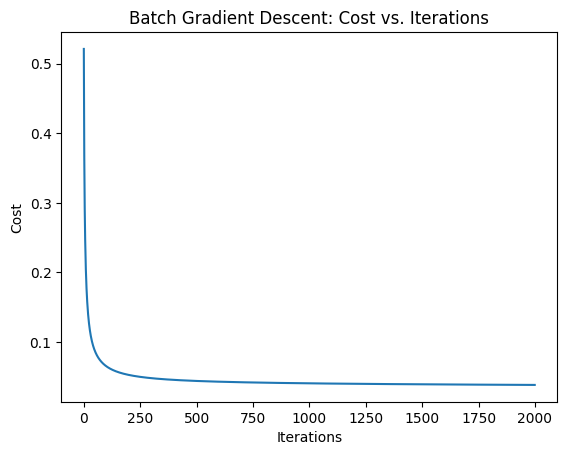

In [24]:
w_final, cost_history = bgd(X_train, y_train, w0, 0.0001, 0.0001, 2000)

plt.plot(cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title("Batch Gradient Descent: Cost vs. Iterations")
plt.show();

In [25]:
# Stochastic Gradient Descent
def sgd(X, y, w0, epsilon, lambda_, iterations, constant=True):
    w = w0
    cost_history = []
    n = X.shape[0] # number of training examples
    t = 1
    
    for iteration in range(iterations):
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(n):
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            s_i = expit(np.dot(x_i, w))
            grad = -x_i * (y_i - s_i) - 2*lambda_ * w
            if not constant:
                epsilon_t = epsilon / t
                t += 1
            else:
                epsilon_t = epsilon
            w = w - epsilon_t * grad # update rule
            
        cost_history.append(compute_cost(X, y, w, lambda_))
    return w, cost_history

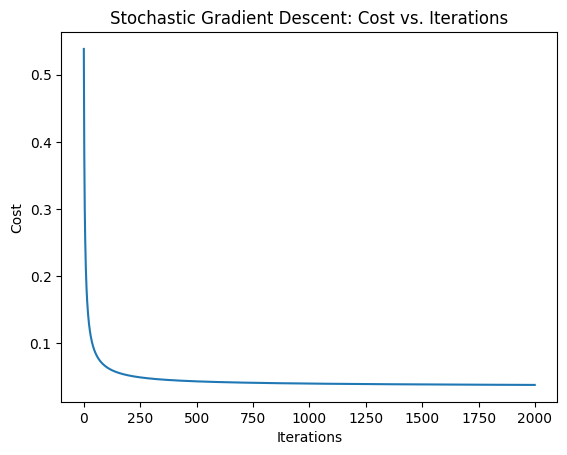

In [26]:
w_final_sgd, cost_history_sgd = sgd(X_train, y_train, w0, 0.0001, 0.0001, 2000)

plt.plot(cost_history_sgd)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title("Stochastic Gradient Descent: Cost vs. Iterations")
plt.show();

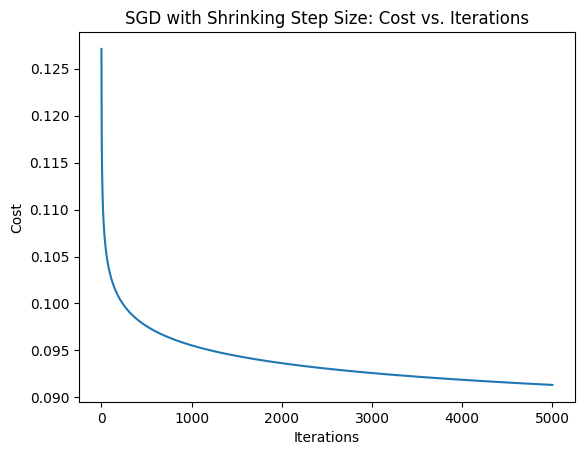

In [21]:
w_final_sgd_shrink, cost_history_sgd_shrink = sgd(X_train, y_train, w0, 1, 0.0001, 5000, constant=False)

plt.plot(cost_history_sgd_shrink)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("SGD with Shrinking Step Size: Cost vs. Iterations")
plt.show();

### kaggle

In [33]:
def results_to_csv(y_test, file_name):
    y_test = y_test.astype(int)
    df = pd.DataFrame({'Category': y_test})
    df.index += 1
    df.to_csv(file_name, index_label='ID')

In [34]:
s_val = expit(X_val @ w_final)
y_pred = (s_val >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.998


In [35]:
s_test = expit(X_test @ w_final) # Logistic regression: s(w_final * x)
y_test = (s_test >= 0.5)

In [36]:
results_to_csv(y_test, 'wine-submission.csv')
print("Submission file 'wine-submission.csv' has been created.")

Submission file 'wine-submission.csv' has been created.
